<a href="https://colab.research.google.com/github/RealGoldenGeneral/SmartVerify-Take-Home-Assignment/blob/main/notebooks/Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Analysis
To analyze suspicious behaviour, we will calculate the mean, median, standard deviation, and interquartile range of intent_drift_score, unique_tables_accessed, entropy of table access sequence, session duration, and sensitive-table access count. We will also evaluate timing statistics between events along with intent drift and entropy thresholds. Finally we will describe the general activity among anomaly patterns.

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Import datasets
df_query = pd.read_csv("../data/new_query.csv")
df_session = pd.read_csv("../data/new_sessions.csv")
df_sequence = pd.read_csv("../data/sequences.csv")

In [3]:
# Create average row estimate feature
df_row_estimates = (
    df_query.groupby('session_id')['row_estimate'].mean().reset_index()
)
df_session = pd.merge(df_session, df_row_estimates, on='session_id', how='left')
df_session.head()

df_sequence["session_id"] = df_session["session_id"]
df_sequence["row_estimate"] = df_session["row_estimate"]
df_sequence.head()

,Unnamed: 0,enterprise_id,user_role,duration_seconds,num_events,declared_intent,is_anomalous_session,slow_drip_exfiltration,broad_retrieval_or_table_scan,intent_drift,...,intent_drift_score,sensitive_table_access_count,select_count,update_count,join_count,aggregation_count,ddl_count,auth_count,session_id,row_estimate
0,0,ent_nexus_beta,1,2270,13,3,0,0,0,0,...,8.931782,0,9.0,1.0,1.0,2.0,0.0,0.0,sess_1000,1642.846154
1,1,ent_corp_alpha,0,1666,15,10,0,0,0,0,...,10.335002,0,8.0,2.0,3.0,2.0,0.0,0.0,sess_1001,3003.666667
2,2,ent_nexus_beta,1,1415,17,0,0,0,0,0,...,9.812710,0,14.0,0.0,2.0,1.0,0.0,0.0,sess_1002,2064.352941
3,3,ent_corp_alpha,4,2816,20,4,0,0,0,0,...,10.691161,0,15.0,2.0,0.0,3.0,0.0,0.0,sess_1003,3515.400000
4,4,ent_corp_alpha,0,1927,14,6,0,0,0,0,...,9.282293,0,7.0,3.0,2.0,2.0,0.0,0.0,sess_1004,1016.285714


## Summary Statistics

In [4]:
# Summary statistics
columns = ['intent_drift_score', 'unique_tables_accessed', 'entropy_table_access_sequence', 'duration_seconds', 'sensitive_table_access_count']
df_session.describe()[columns]

,intent_drift_score,unique_tables_accessed,entropy_table_access_sequence,duration_seconds,sensitive_table_access_count
count,230.000000,230.000000,230.000000,230.000000,230.000000
mean,11.212896,3.717391,1.680179,1768.508696,0.200000
std,3.953111,1.731585,0.506545,1652.860867,1.103389
min,7.704210,2.000000,0.713852,458.000000,0.000000
25%,9.423379,3.000000,1.444629,1089.750000,0.000000
50%,10.129631,3.000000,1.554585,1403.500000,0.000000
75%,11.688806,4.000000,1.885189,1769.500000,0.000000
max,47.271868,14.000000,3.597472,10111.000000,10.000000


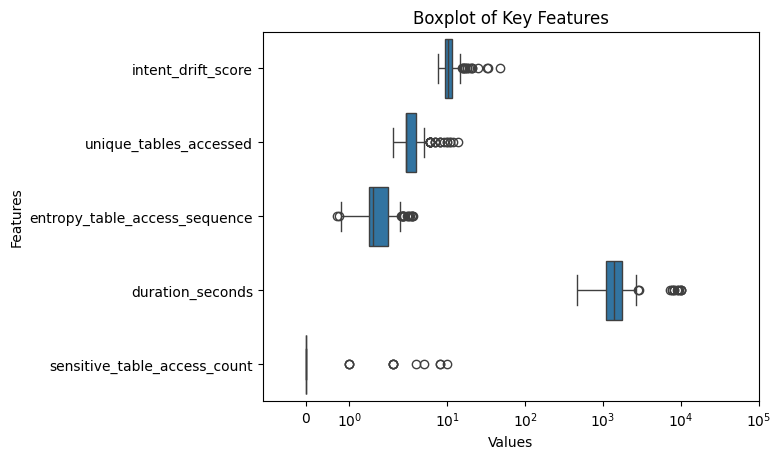

In [5]:
# Boxplot for key features
df_melted = df_session[columns].melt(var_name='Features', value_name='Values')
sns.boxplot(data=df_melted, x='Values', y='Features')
plt.title("Boxplot of Key Features")
plt.xlabel("Values")
plt.ylabel("Features")
plt.xscale('symlog')
plt.xlim(-1, 100000)
plt.show()

## Inter-event Timing Statistics

In [6]:
# Distribution of query events over time
df_query = df_query.sort_values(by='timestamp')
df_query['time_delta'].describe()

,time_delta
count,3309.000000
mean,112.251435
std,136.414222
min,0.000000
25%,24.000000
50%,71.000000
75%,151.000000
max,1709.000000


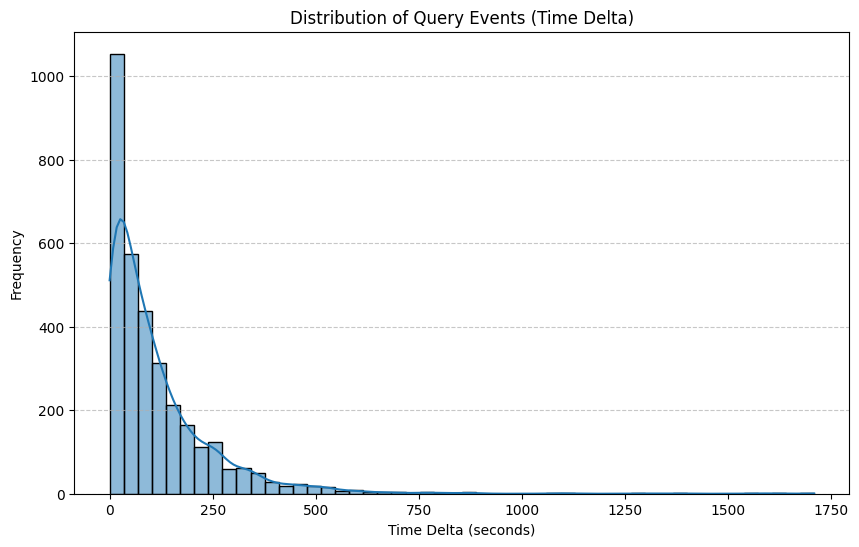

In [7]:
# Plot distribution of query events over time delta
plt.figure(figsize=(10, 6))
sns.histplot(data=df_query, x='time_delta', bins=50, kde=True)
plt.title("Distribution of Query Events (Time Delta)")
plt.xlabel("Time Delta (seconds)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

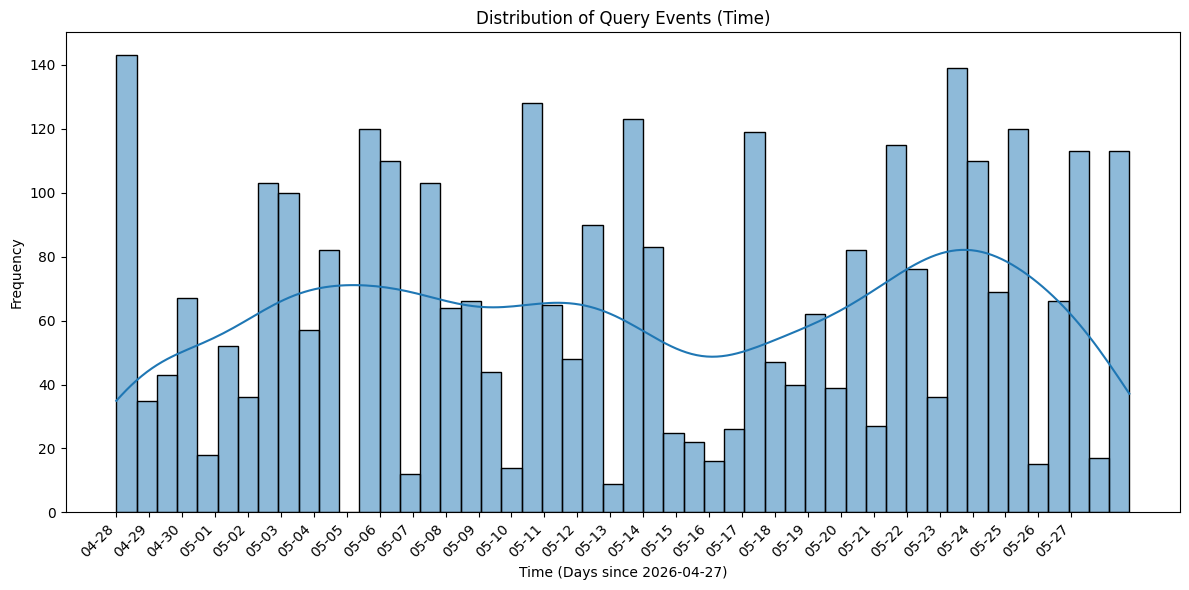

In [8]:
import matplotlib.dates as mdates

# Plot distirbution of query events over time
df_query['timestamp_dt'] = pd.to_datetime(df_query['timestamp'])
timestamp_unix_seconds = df_query['timestamp_dt'].astype(int) / 10**9

# Convert Unix seconds back to datetime objects for plotting
# We need a reference point. The minimum timestamp in the data will serve as a good base.
min_timestamp_dt = df_query['timestamp_dt'].min()
# Calculate the time in days relative to the minimum timestamp for better readability on the axis
time_since_min_days = (df_query['timestamp_dt'] - min_timestamp_dt).dt.total_seconds() / (60 * 60 * 24)

plt.figure(figsize=(12, 6))
sns.histplot(x=time_since_min_days, bins=50, kde=True)

# Get current axis
ax = plt.gca()

# Calculate actual dates for the ticks based on the min_timestamp_dt
# We'll create new tick locations and labels
start_date = min_timestamp_dt.date()
end_date = df_query['timestamp_dt'].max().date()

# Generate tick locations in 'days since start' for date intervals (e.g., every 5 days)
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
tick_locations = [(d - min_timestamp_dt).days for d in date_range]
tick_labels = [d.strftime('%m-%d') for d in date_range]

# Filter out tick locations that are outside the plot's data range, if any
valid_tick_locations = [loc for loc in tick_locations if loc >= 0 and loc <= time_since_min_days.max()]
valid_tick_labels = [label for loc, label in zip(tick_locations, tick_labels) if loc >= 0 and loc <= time_since_min_days.max()]

ax.set_xticks(valid_tick_locations)
ax.set_xticklabels(valid_tick_labels, rotation=45, ha='right')

plt.title("Distribution of Query Events (Time)")
plt.xlabel(f"Time (Days since {min_timestamp_dt.strftime('%Y-%m-%d')})")
plt.ylabel("Frequency")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Baselines

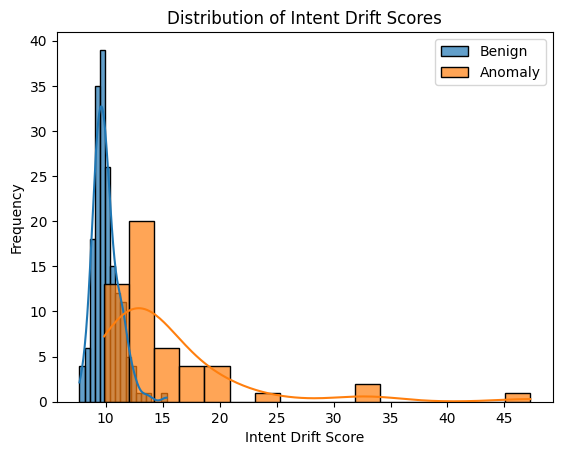

In [9]:
# Threshold analysis for intent drift
df_benign = df_session[df_session['is_anomalous_session'] == 0]['intent_drift_score']
df_anomaly = df_session[df_session['is_anomalous_session'] == 1]['intent_drift_score']

sns.histplot(data=df_benign, label='Benign', kde=True, alpha=0.7)
sns.histplot(data=df_anomaly, label='Anomaly', kde=True, alpha=0.7)
plt.title("Distribution of Intent Drift Scores")
plt.xlabel("Intent Drift Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

This visualization shows that the baseline of anomalous labels is around 12 intent drift score. This score is around the point where we can confidently say the activity is suspicious as there are more anomalies than benign sessions.

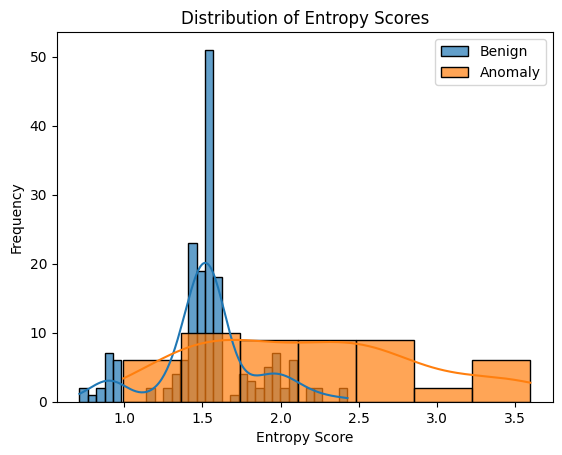

In [10]:
# Threshold analysis for entropy
df_benign = df_session[df_session['is_anomalous_session'] == 0]['entropy_table_access_sequence']
df_anomaly = df_session[df_session['is_anomalous_session'] == 1]['entropy_table_access_sequence']

sns.histplot(data=df_benign, label='Benign', kde=True, alpha=0.7)
sns.histplot(data=df_anomaly, label='Anomaly', kde=True, alpha=0.7)
plt.title("Distribution of Entropy Scores")
plt.xlabel("Entropy Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The entropy baseline would be around 2.0 because the score would be the point where more sessions are anomalies than normal.

# Descriptive Analysis
Descriptive analysis across patterns to determine typical behaviour

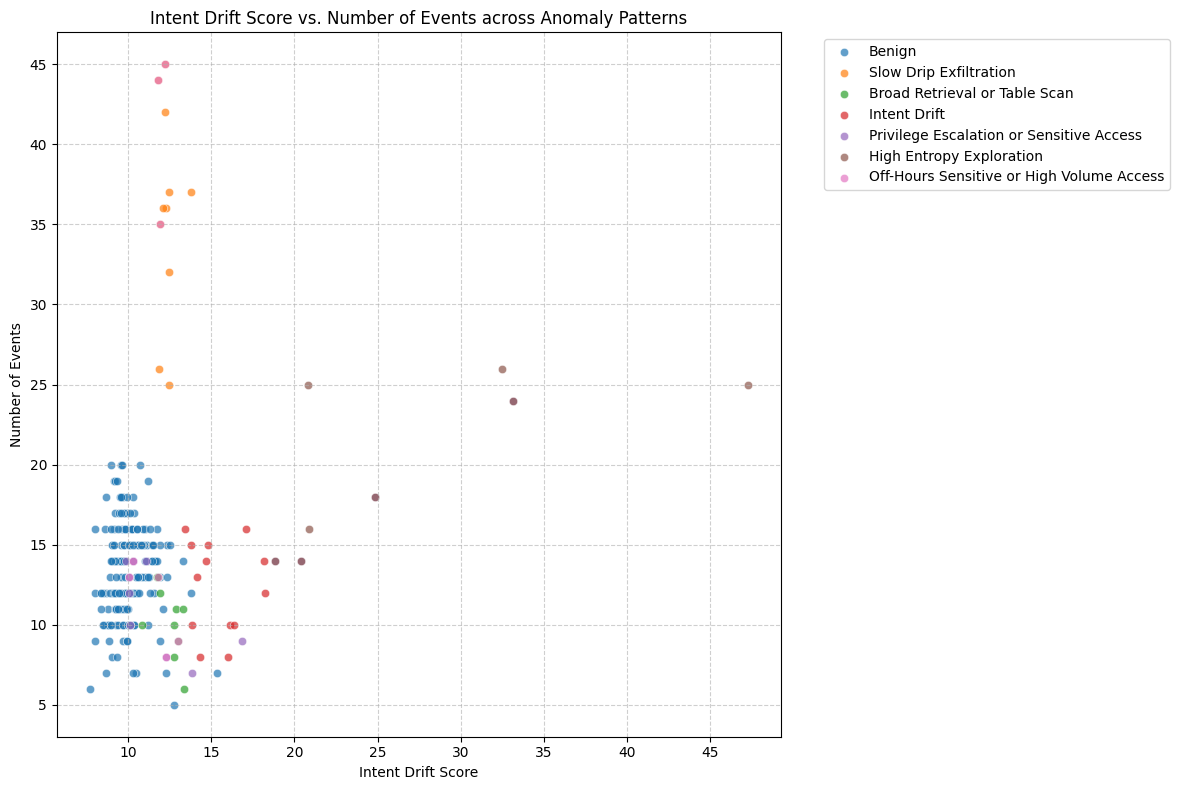

In [11]:
# Intent Drift Score and Number of Events across patterns of anomalies
df_benign_sessions = df_session[df_session['is_anomalous_session'] == 0]
df_sde_sessions = df_session[df_session['slow_drip_exfiltration'] == 1]
df_br_or_ts_sessions = df_session[df_session['broad_retrieval_or_table_scan'] == 1]
df_id_sessions = df_session[df_session['intent_drift'] == 1]
df_pe_or_sav_sessions = df_session[df_session['privilege_escalation_or_sensitive_access_violation'] == 1]
df_hee_sessions = df_session[df_session['high_entropy_exploration'] == 1]
df_ohs_or_hva_sessions = df_session[df_session['off_hours_sensitive_or_high_volume_access'] == 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_benign_sessions, x='intent_drift_score', y='num_events', label='Benign', alpha=0.7)
sns.scatterplot(data=df_sde_sessions, x='intent_drift_score', y='num_events', label='Slow Drip Exfiltration', alpha=0.7)
sns.scatterplot(data=df_br_or_ts_sessions, x='intent_drift_score', y='num_events', label='Broad Retrieval or Table Scan', alpha=0.7)
sns.scatterplot(data=df_id_sessions, x='intent_drift_score', y='num_events', label='Intent Drift', alpha=0.7)
sns.scatterplot(data=df_pe_or_sav_sessions, x='intent_drift_score', y='num_events', label='Privilege Escalation or Sensitive Access', alpha=0.7)
sns.scatterplot(data=df_hee_sessions, x='intent_drift_score', y='num_events', label='High Entropy Exploration', alpha=0.7)
sns.scatterplot(data=df_ohs_or_hva_sessions, x='intent_drift_score', y='num_events', label='Off-Hours Sensitive or High Volume Access', alpha=0.7)

plt.title("Intent Drift Score vs. Number of Events across Anomaly Patterns")
plt.xlabel("Intent Drift Score")
plt.ylabel("Number of Events")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This scatter plot clearly identifies slow drip exfiltrations, intent drift, privilege escalation or sensitive access, and high entropy exploration well as the clusters seperate themselves from each other as seen by the gaps between benign, intent drift, high entropy exploration and slow drip exfiltration. The scatterplot, however fails to seperate broad retrieval or table scan and off-hours sensitive or high volume access from each other, suggesting that they can be seperated through other means.

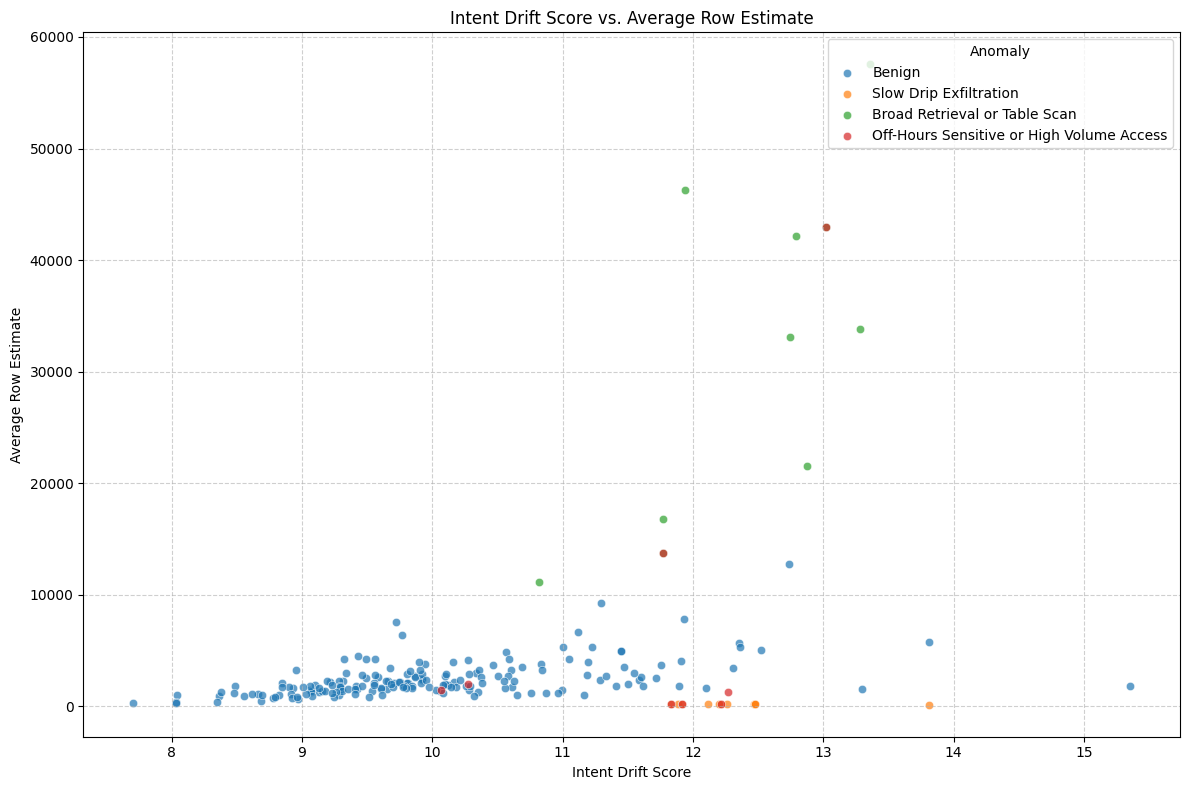

In [12]:
# Seperate BRTS and OHSHVA anomalies from other sessions
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_benign_sessions, x='intent_drift_score', y='row_estimate', label='Benign', alpha=0.7)
sns.scatterplot(data=df_sde_sessions, x='intent_drift_score', y='row_estimate', label='Slow Drip Exfiltration', alpha=0.7)
sns.scatterplot(data=df_br_or_ts_sessions, x='intent_drift_score', y='row_estimate', label='Broad Retrieval or Table Scan', alpha=0.7)
sns.scatterplot(data=df_ohs_or_hva_sessions, x='intent_drift_score', y='row_estimate', label='Off-Hours Sensitive or High Volume Access', alpha=0.7)
plt.title("Intent Drift Score vs. Average Row Estimate")
plt.xlabel("Intent Drift Score")
plt.ylabel("Average Row Estimate")
plt.legend(title='Anomaly', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This visualization proves that the average row estimate could split off broad retrieval or table scan anomalies from benign and slow drip exfiltration. Because of the varying nature of off-hours sensitive or high volume access anomalies, separating them from other sessions will be the hardest to seperate from other types.

# Baseline Model
For our baseline model, we have elected to use support vector machines. This is because SVMs can perform consistently well with training and is memory efficent. SVMs provide classification boundaries and clear visualizations of clusters of information. SVMs are more memory efficent than LSTMs and are not vulnerable to the exploding gradient problem, but have more expensive cross validation when compared to LSTMs.

In [13]:
# Load libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
# Preprocessing
columns = ['intent_drift_score', 'unique_tables_accessed', 'entropy_table_access_sequence', 'duration_seconds', 'sensitive_table_access_count', 'row_estimate', 'num_events', 'cross_table_join_count', 'time_delta_mean', 'confidence_mean', 'user_role', 'declared_intent','select_count', 'update_count', 'join_count', 'aggregation_count', 'ddl_count', 'auth_count']
X = df_sequence[columns]
y = df_sequence['is_anomalous_session']

def preprocess_data(X, y):
  scaler = StandardScaler()
  # fit_transform returns a numpy array; convert it back to a DataFrame to use pandas methods or use train_test_split
  X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

  # Using train_test_split is generally cleaner for multi-step splits
  X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
  X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

  return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(X, y)

In [16]:
# Cross validation
from sklearn.model_selection import GridSearchCV
def cross_validate(X_train, y_train):
  svm_classifier = SVC(random_state=42, class_weight="balanced")
  param_grid = {'kernel': ['linear', 'rbf'], 'C': [0.1, 1, 10]}
  grid_search = GridSearchCV(svm_classifier, param_grid, cv=5)
  grid_search.fit(X_train, y_train)
  return grid_search.best_estimator_

svc = cross_validate(X_train, y_train)

In [18]:
# Training SVM
def train_svm(X_train, y_train):
  svc.fit(X_train, y_train)

svm_classifier = train_svm(X_train, y_train)
# Test SVM
def test_svm(svm_classifier, X_test, y_test):
  y_pred = svm_classifier.predict(X_test)
  print("Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred))
  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))

test_svm(svc, X_test, y_test)

Confusion Matrix:
[[27  1]
 [ 0  7]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        28
           1       0.88      1.00      0.93         7

    accuracy                           0.97        35
   macro avg       0.94      0.98      0.96        35
weighted avg       0.97      0.97      0.97        35



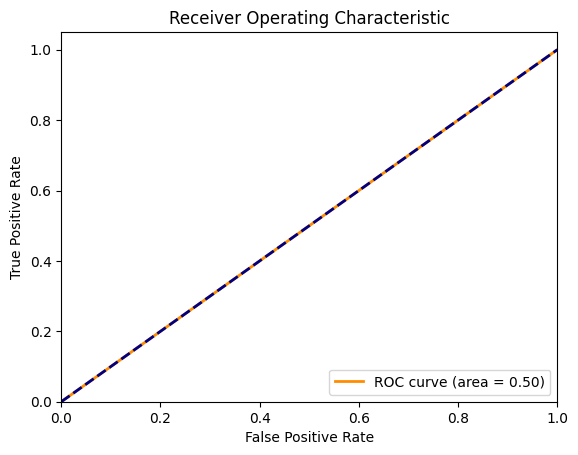

In [20]:
# Visualize ROC curve
from sklearn.metrics import roc_curve, auc
def visualize_roc_curve(svm_classifier, X, y):
  y_pred_prob = svm_classifier.decision_function(X)
  fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
  roc_auc = auc(fpr, tpr)
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic')
  plt.legend(loc="lower right")
  plt.show()
  return fpr, tpr, thresholds

fpr, tpr, thresholds = visualize_roc_curve(svc, X, y)

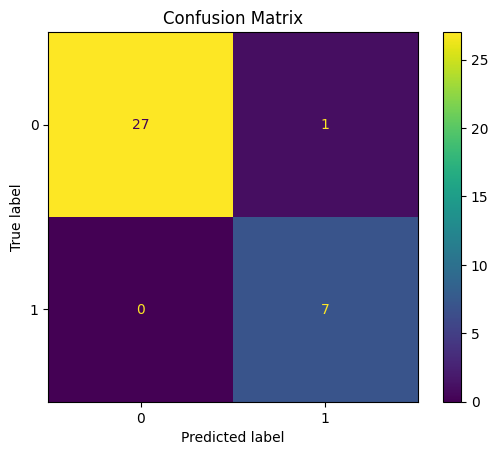

In [23]:
# Visualize confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
def visualize_confusion_matrix(svm_classifier, X_test, y_test):
  cm = confusion_matrix(y_test, svm_classifier.predict(X_test))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
  disp.plot()
  plt.title("Confusion Matrix")
  plt.show()

visualize_confusion_matrix(svc, X_test, y_test)